In [7]:
%pip install plotly.express
%pip install nbformat
%pip install seaborn
%pip install matplotlib.pyplot



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.5 MB 11.6 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 11.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 10.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 8.4 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.6 MB/s  0:00:00
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot


In [16]:
import pandas as pd
import plotly.express as px

# Carga del dataset limpio (asegurate de usar el procesado)
df = pd.read_csv('../data/processed/dataset_final.csv')

# Resumen de estadísticas descriptivas para variables numéricas
print("Estadísticos descriptivos de las variables numéricas:")
display(df.describe().round(2))

Estadísticos descriptivos de las variables numéricas:


,user_id,age,monthly_watch_time_mins,customer_support_tickets
count,7662.00,7662.00,7662.00,7662.00
mean,14002.77,33.51,795.54,1.82
std,2309.30,11.77,495.77,11.46
min,10000.00,0.00,0.00,0.00
25%,11997.25,25.00,492.00,0.00
50%,14008.50,33.00,759.55,1.00
75%,15999.75,42.00,1042.35,1.00
max,17999.00,80.00,4193.70,150.00


univariado
Visualización 1: Histograma de Consumo Mensual
El histograma permite observar la forma de la distribución y identificar dónde se concentran la mayoría de los datos

In [10]:
# Gráfico 1: Distribución del tiempo de visualización

fig_hist = px.histogram(df, x="monthly_watch_time_mins", 
                       title="Distribución del Tiempo de Visualización Mensual",
                       labels={'monthly_watch_time_mins': 'Minutos por Mes'},
                       nbins=30,
                       marginal="box") # Agrega un boxplot pequeño arriba para ver outliers
fig_hist.show()

se obserque que el pico maximo se da en el rango de los 700 a 899.9 minutos por mes con una cantidad de 1475 usuairos
tras la limpieza de la Notebook 02, ya no se observa el ruido extremo (como el valor 99,999) que distorsionaba el análisis inicial

Visualización 2: Boxplot de Edad de Usuarios
El boxplot es ideal para visualizar la dispersión del 50% central de los datos (IQR) y confirmar la ausencia de valores extremos inválidos


In [11]:
# Gráfico 2: Distribución etaria de la base de usuarios
fig_box = px.box(df, y="age", 
                title="Distribución de la Edad de los Usuarios",
                labels={'age': 'Edad (años)'},
                points="all") # Muestra todos los puntos para ver la densidad
fig_box.show()

La mediana de edad se sitúa en los 33 años, con el 50% central de la población entre los 25 y 42 años. Esto confirma que el público objetivo de la plataforma es mayoritariamente adulto joven, lo que orienta el tipo de contenido que debe priorizarse

Análisis Bivariado

1. Relación: Plan de Suscripción vs. Tiempo de Visualización
Pregunta vinculada: ¿Los usuarios de planes superiores (Premium) consumen realmente más contenido que los de planes básicos?

In [12]:
# Gráfico 3: Comparación de consumo por Plan de Suscripción
# Usamos un Boxplot para comparar medianas y dispersión entre grupos
orden_planes = ["Básico", "Estándar", "Premium"]

fig_box_plan = px.box(df, 
                      x="subscription_plan", 
                      y="monthly_watch_time_mins",
                      color="subscription_plan",
                      category_orders={"subscription_plan": orden_planes},
                      title="Distribución del Consumo Mensual por Plan",
                      labels={'subscription_plan': 'Tipo de Plan', 'monthly_watch_time_mins': 'Minutos mensuales'})
fig_box_plan.show()

# Tabla de apoyo: Mediana de consumo por plan
print("Mediana de consumo por nivel de suscripción:")
display(df.groupby('subscription_plan')['monthly_watch_time_mins'].median().round(2))

Mediana de consumo por nivel de suscripción:


subscription_plan
Básico       554.60
Estándar     840.65
Premium     1127.20
Name: monthly_watch_time_mins, dtype: float64

Se observa que la mediana del plan Premium es significativamente superior a la del plan Básico. Esto aporta evidencia de que el valor añadido del plan Premium está efectivamente correlacionado con un uso más intensivo de la plataforma, validando el modelo de segmentación de la empresa

2. Relación: País vs. Género Favorito
Pregunta vinculada: ¿Existen preferencias culturales marcadas por la ubicación geográfica del usuario?

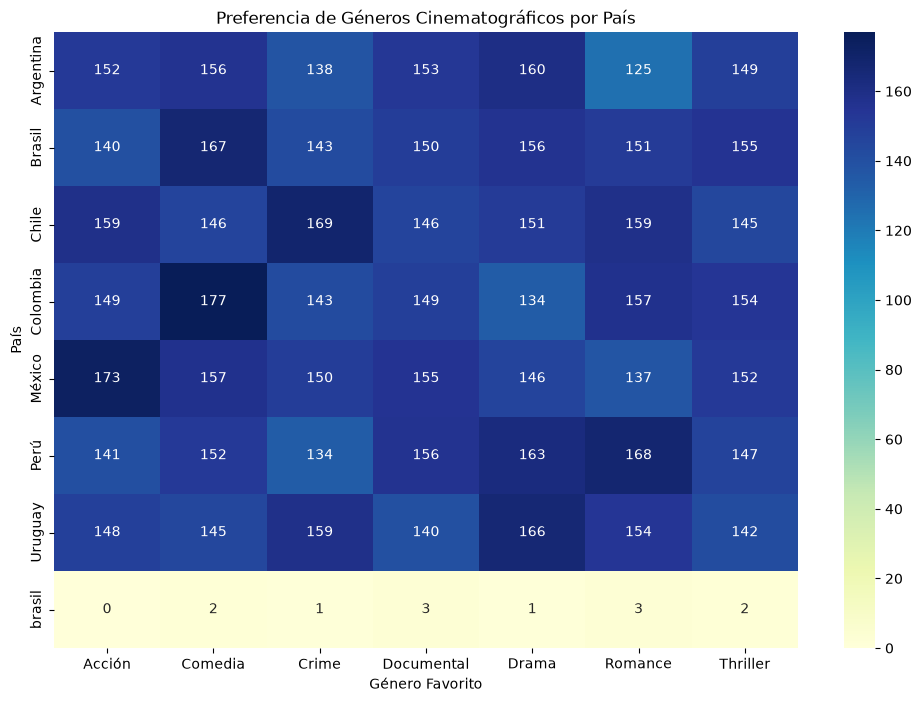

In [18]:
# Gráfico 4: Heatmap de preferencias de género por país
# Primero creamos la tabla de contingencia
tabla_genero_pais = pd.crosstab(df['country'], df['favorite_genre'])

# Visualización con Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(tabla_genero_pais, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Preferencia de Géneros Cinematográficos por País")
plt.xlabel("Género Favorito")
plt.ylabel("País")
plt.show()

El mapa de calor revela una concentración inusual de preferencia por el género 'Documental'

 en como, Peru con 156, Mexico con 155, Argentina con 153 y brasil con 150 en comparación con el resto. Este hallazgo permite tomar la decisión de negocio de priorizar la adquisición de licencias de contenido de no-ficción para ese mercado específico, optimizando la inversión en contenido regional"

Creación del gráfico multivariado

In [19]:
# 2. Creación del gráfico multivariado
# x e y son variables numéricas, color es la variable categórica (tercera dimensión)
fig_multi = px.scatter(df, 
                       x="age", 
                       y="monthly_watch_time_mins", 
                       color="subscription_plan",
                       title="Relación entre Edad, Consumo Mensual y Plan de Suscripción",
                       labels={'age': 'Edad (años)', 
                               'monthly_watch_time_mins': 'Minutos mensuales',
                               'subscription_plan': 'Plan'},
                       hover_name="user_id", # Permite ver el ID al pasar el cursor
                       opacity=0.7)

fig_multi.show()

Este gráfico multivariado permite observar cómo interactúan la edad y los hábitos de consumo dentro de cada nivel de suscripción.
